In [ ]:
%load_ext autoreload
%autoreload 2
%cd ../..

In [47]:
import os
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from tqdm import tqdm

warnings.filterwarnings("ignore")

from notebooks.utils import *

In [52]:
MOLSTRAL_PATH = Path("MolGenOutput/test_ood")
FIG_PATH = "MolGenDocking-latex/Figures/Results/MolGen"
os.makedirs(FIG_PATH, exist_ok=True)

files = [f for d in MOLSTRAL_PATH.iterdir() for f in d.iterdir() if "" in str(f) and str(f).endswith("_scored.jsonl")]
# files = [Path("MolGenOutput/test_ood/RL-Mistral-24B-100/RL-Mistral-24B-100_0_scored.jsonl")]
files = sorted(files)[::-1]

print("Total files:", len(files))
save_df_path = Path("MolGenOutput/test_ood.csv")
if save_df_path.exists():
    df = pd.read_csv(save_df_path)
else:
    df = load_molgen_results(files[:])
    df.to_csv(save_df_path, index=False)
df = df[(df.n_props == 2)]

Total files: 130


In [53]:
df.Model.unique()

<ArrowStringArray>
[        'gpt-oss',         'gemma-4',         'gemma-3',          'ether0',
            'ZINC',  'RL-Molstral-g8',  'RL-Molstral-g4', 'RL-Molstral-g16',
      'RL-Mistral',      'Qwen3-Next',           'Qwen3', 'Mistral-Small-4',
      'MiniMax-M2',       'Llama-3.3',         'R1-Qwen',        'R1-Llama',
    'ChemDFM-v2.0',       'ChemDFM-R']
Length: 18, dtype: str

In [71]:
MODELS = ["gemma-4", "RL-Molstral-g16", "Mistral-Small-4", "ChemDFM-R"]

df = df[df.Model.isin(MODELS)]
df = df[df.validity == 1]
df

,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model
128256,17110390723,0.741788,gemma-4-31B-it,2,"sample_1156374_model_0,QED","minimize,above",CC1=CC=C(C=C1)C2=CC=NC(C=C2)C3=CC=CC=C3C(=O)NC...,1,valid,gemma-4
128257,17110390723,0.621691,gemma-4-31B-it,2,"sample_1156374_model_0,QED","minimize,above",N[C@@H](C(=O)O)CS(=O)(N)CC1=CC=C(F)C=C1,1,valid,gemma-4
128258,17110390723,0.728697,gemma-4-31B-it,2,"sample_1156374_model_0,QED","minimize,above",NC1=CC(C(=O)O)C=C(O)C=C1N=NC2=CC=C(S(=O)(=O)NC...,1,valid,gemma-4
128259,17110390723,0.707814,gemma-4-31B-it,2,"sample_1156374_model_0,QED","minimize,above",CC(C)NC(=O)C1=CC=C(NC(=O)CN2CCN(C)CC2)C=C1,1,valid,gemma-4
128260,17110390723,0.877496,gemma-4-31B-it,2,"sample_1156374_model_0,QED","minimize,above",NC(C(=O)O)c1ccc(S(=O)(=O)N2CCC(CC2)C(=O)O)cc1,1,valid,gemma-4
...,...,...,...,...,...,...,...,...,...,...
2090538,37891039142235,0.692098,ChemDFM-R-14B,2,"sample_1171343_model_0,CalcTPSA","minimize,above",CC(C)NC[C@H](O)c1ccc(O)cc1,1,valid,ChemDFM-R
2090539,37891039142235,0.938882,ChemDFM-R-14B,2,"sample_1171343_model_0,CalcTPSA","minimize,above",CC(C)(C)OC(=O)N[C@H]1CCCCC/C=C/[C@H]2C[C@@]2(C...,1,valid,ChemDFM-R
2090540,37891039142235,0.625500,ChemDFM-R-14B,2,"sample_1171343_model_0,CalcTPSA","minimize,above",O=C(O)c1cncc(Br)c1,1,valid,ChemDFM-R
2090541,37891039142235,0.867179,ChemDFM-R-14B,2,"sample_1171343_model_0,CalcTPSA","minimize,above",Cc1cccc(C)c1NC(=O)CN1CCN(CCCOc2ccc(F)cc2)CC1,1,valid,ChemDFM-R


In [95]:
prompt_ids = df[df.objectives.apply(lambda x: "minimize" in x)].groupby("prompt_id").reward.std().sort_values(ascending=False)[:3].index.tolist()
df_filtered = df[df.prompt_id.isin(prompt_ids)]
df_filtered.properties.unique()

<ArrowStringArray>
[                     'SA,3az8_S21_D_231',
 'sample_419920_model_0,CalcFractionCSP3',
               'SA,sample_941067_model_0']
Length: 3, dtype: str

In [96]:
# Get top 3 best generations per prompt_id / Model
top3_per_group = df_filtered.groupby(["prompt_id", "Model"]).sample(3).reset_index()

print(f"Total generations: {len(df_filtered)}")
print(f"Total top 3 generations: {len(top3_per_group)}")
print(f"\nTop 3 generations per prompt_id/Model:\n")
top3_per_group

Total generations: 1175
Total top 3 generations: 36

Top 3 generations per prompt_id/Model:



,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model
0,2012516,166210391330,0.749667,ChemDFM-R-14B,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",O=C(O)c1cc(Cl)c(Cl)[nH]c1=O,1,valid,ChemDFM-R
1,2012538,166210391330,0.000000,ChemDFM-R-14B,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",COc1cc(OC)c2c(c1)OC1c3ccc(O)c(OC)c3OCC21,1,valid,ChemDFM-R
2,2012467,166210391330,0.000000,ChemDFM-R-14B,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",CCCCCCC(O)c1ccccc1,1,valid,ChemDFM-R
3,1292759,166210391330,0.846168,Mistral-Small-4-128B,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",c1ccc(cc1)-c2ccccc2-c3ccncc3,1,valid,Mistral-Small-4
4,1211592,166210391330,0.935682,Mistral-Small-4-128B,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",O=C(Nc1ccccn1)c2cnn(c2c3ccccc3)c4c(Cl)c(Cl)ccc4,1,valid,Mistral-Small-4
5,1211566,166210391330,0.868476,Mistral-Small-4-128B,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",OC(c1ccccc1)(c2ccccc2)c3ccccc3,1,valid,Mistral-Small-4
6,749831,166210391330,0.815782,RL-Molstral-g16,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",Fc1ccc(cc1)C(=O)Nc2ccccc2,1,valid,RL-Molstral-g16
7,749814,166210391330,0.859433,RL-Molstral-g16,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",NC(=O)C1=CC=C(C=C1)C2=CC=C(C=C2)Cl,1,valid,RL-Molstral-g16
8,749873,166210391330,0.794355,RL-Molstral-g16,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",O=C(O)C1=CC=C(C=C1)C2=CC=CC=C2,1,valid,RL-Molstral-g16
9,177578,166210391330,1.000000,gemma-4-31B-it,2,"sample_419920_model_0,CalcFractionCSP3","minimize,below",O=C(NC1=CC=CC=C1)C2=CC=NN(C2C3=CC=C(C=C3)Cl)C4...,1,valid,gemma-4


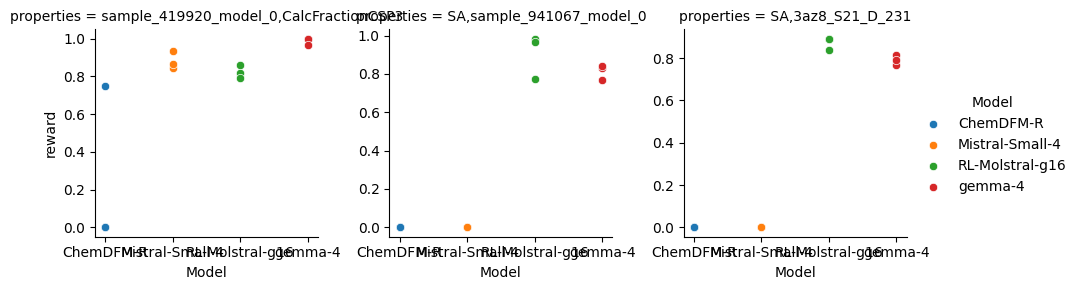

In [97]:
import seaborn as sns

sns.FacetGrid(top3_per_group, col="properties", hue="Model", col_wrap=3, sharex=False, sharey=False).map(sns.scatterplot, "Model", "reward").add_legend()

In [104]:
top3_per_group = top3_per_group[top3_per_group.prompt_id !=prompt_ids[0]]

In [106]:
top3_per_group

,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model,receptor_file
12,2064963,2053103906320,0.000000,ChemDFM-R-14B,2,"SA,sample_941067_model_0","below,minimize",C[C@@H]1CC[C@H](C)CC(=O)C1,1,valid,ChemDFM-R,"data/molgendata/pdb_files/SA,sample_941067_mod..."
13,2065008,2053103906320,0.000000,ChemDFM-R-14B,2,"SA,sample_941067_model_0","below,minimize",Cc1ccc(/C(C)=C/C(O)(c2ccc(C)cc2)c2ccc(C)cc2)cc1,1,valid,ChemDFM-R,"data/molgendata/pdb_files/SA,sample_941067_mod..."
14,2064984,2053103906320,0.000000,ChemDFM-R-14B,2,"SA,sample_941067_model_0","below,minimize",Cc1ccccc1C(=O)Nc1ccc([C@@H](C)N(Cc2ccnc(N)c2)C...,1,valid,ChemDFM-R,"data/molgendata/pdb_files/SA,sample_941067_mod..."
15,1257619,2053103906320,0.000000,Mistral-Small-4-128B,2,"SA,sample_941067_model_0","below,minimize",C1=CC=C(C=C1)\C=C(/C=C\C(=O)O)C,1,valid,Mistral-Small-4,"data/molgendata/pdb_files/SA,sample_941067_mod..."
16,1310435,2053103906320,0.000000,Mistral-Small-4-128B,2,"SA,sample_941067_model_0","below,minimize",OCC1CCCC(=O)C1,1,valid,Mistral-Small-4,"data/molgendata/pdb_files/SA,sample_941067_mod..."
17,1257659,2053103906320,0.000000,Mistral-Small-4-128B,2,"SA,sample_941067_model_0","below,minimize",CN1CCC[C@H]1Cc2ccccc2,1,valid,Mistral-Small-4,"data/molgendata/pdb_files/SA,sample_941067_mod..."
18,789307,2053103906320,0.983425,RL-Molstral-g16,2,"SA,sample_941067_model_0","below,minimize",NC(=O)C1=CC=C(C=C1)CCC2CCN(CC2)CC3=CC=C(C=C3)O,1,valid,RL-Molstral-g16,"data/molgendata/pdb_files/SA,sample_941067_mod..."
19,789323,2053103906320,0.966954,RL-Molstral-g16,2,"SA,sample_941067_model_0","below,minimize",CC(C)C1=CC=C(C=C1)NC(=O)C2=CC=C(C=C2)C3=CC=CC=C3,1,valid,RL-Molstral-g16,"data/molgendata/pdb_files/SA,sample_941067_mod..."
20,789353,2053103906320,0.775323,RL-Molstral-g16,2,"SA,sample_941067_model_0","below,minimize",FC1=CC=C(C=C1)NC(=O)C2=CC=C(OC)C=C2,1,valid,RL-Molstral-g16,"data/molgendata/pdb_files/SA,sample_941067_mod..."
21,230043,2053103906320,0.765833,gemma-4-31B-it,2,"SA,sample_941067_model_0","below,minimize",CC(C)CC1=CC=C(C=CC(=O)O)C=C1,1,valid,gemma-4,"data/molgendata/pdb_files/SA,sample_941067_mod..."


In [108]:
from molrgen.reward.verifiers.generation_reward.oracles.docking_utils.docking_soft import AutoDockGPUDocking
from molrgen.reward.verifiers.generation_reward.oracles.docking_utils.preparators import (
    MeekoLigandPreparator,
)
import ray

preparator_class = MeekoLigandPreparator
preparator = preparator_class(
    conformer_attempts=10,
    n_conformers=1,
)

docking_actor = AutoDockGPUDocking.options(num_gpus=1).remote(cmd="autodock_gpu_128wi", pdbqt_output_dir = "./notebooks/docking_res", print_msgs=True, print_output=False, preparator=preparator)

In [109]:
def compute_docking_score(smiles, receptor_file):
    assert Path(receptor_file).exists(), f"{receptor_file} does not exist"
    score = docking_actor.dock_smis.remote(smi = smiles, receptor_file = receptor_file)
    return score


In [110]:
top3_per_group["receptor_file"] = top3_per_group.properties.apply(lambda x: "data/molgendata/pdb_files/" + x.replace("SA,", "") + ".pdb")

In [112]:
from tqdm.auto import tqdm
tqdm.pandas()
    
for prop in top3_per_group.receptor_file.unique():
    print(f"Computing docking scores for property: {prop}")
    mask = top3_per_group.receptor_file == prop
    smiles = top3_per_group.loc[mask, "smiles"].tolist()
    scores = ray.get(
        compute_docking_score(smiles, prop)
    )
    top3_per_group.loc[mask, "docking_score"] = scores

Computing docking scores for property: data/molgendata/pdb_files/sample_941067_model_0.pdb
Computing docking scores for property: data/molgendata/pdb_files/3az8_S21_D_231.pdb


In [113]:
top3_per_group

,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model,receptor_file,docking_score
12,2064963,2053103906320,0.000000,ChemDFM-R-14B,2,"SA,sample_941067_model_0","below,minimize",C[C@@H]1CC[C@H](C)CC(=O)C1,1,valid,ChemDFM-R,data/molgendata/pdb_files/sample_941067_model_...,score=-3.94 pose=None success=True smi='C[C@@H...
13,2065008,2053103906320,0.000000,ChemDFM-R-14B,2,"SA,sample_941067_model_0","below,minimize",Cc1ccc(/C(C)=C/C(O)(c2ccc(C)cc2)c2ccc(C)cc2)cc1,1,valid,ChemDFM-R,data/molgendata/pdb_files/sample_941067_model_...,score=-10.64 pose=None success=True smi='Cc1cc...
14,2064984,2053103906320,0.000000,ChemDFM-R-14B,2,"SA,sample_941067_model_0","below,minimize",Cc1ccccc1C(=O)Nc1ccc([C@@H](C)N(Cc2ccnc(N)c2)C...,1,valid,ChemDFM-R,data/molgendata/pdb_files/sample_941067_model_...,score=-10.33 pose=None success=True smi='Cc1cc...
15,1257619,2053103906320,0.000000,Mistral-Small-4-128B,2,"SA,sample_941067_model_0","below,minimize",C1=CC=C(C=C1)\C=C(/C=C\C(=O)O)C,1,valid,Mistral-Small-4,data/molgendata/pdb_files/sample_941067_model_...,score=-6.67 pose=None success=True smi='C1=CC=...
16,1310435,2053103906320,0.000000,Mistral-Small-4-128B,2,"SA,sample_941067_model_0","below,minimize",OCC1CCCC(=O)C1,1,valid,Mistral-Small-4,data/molgendata/pdb_files/sample_941067_model_...,score=-5.32 pose=None success=True smi='OCC1CC...
17,1257659,2053103906320,0.000000,Mistral-Small-4-128B,2,"SA,sample_941067_model_0","below,minimize",CN1CCC[C@H]1Cc2ccccc2,1,valid,Mistral-Small-4,data/molgendata/pdb_files/sample_941067_model_...,score=-6.75 pose=None success=True smi='CN1CCC...
18,789307,2053103906320,0.983425,RL-Molstral-g16,2,"SA,sample_941067_model_0","below,minimize",NC(=O)C1=CC=C(C=C1)CCC2CCN(CC2)CC3=CC=C(C=C3)O,1,valid,RL-Molstral-g16,data/molgendata/pdb_files/sample_941067_model_...,score=-10.96 pose=None success=True smi='NC(=O...
19,789323,2053103906320,0.966954,RL-Molstral-g16,2,"SA,sample_941067_model_0","below,minimize",CC(C)C1=CC=C(C=C1)NC(=O)C2=CC=C(C=C2)C3=CC=CC=C3,1,valid,RL-Molstral-g16,data/molgendata/pdb_files/sample_941067_model_...,score=-10.39 pose=None success=True smi='CC(C)...
20,789353,2053103906320,0.775323,RL-Molstral-g16,2,"SA,sample_941067_model_0","below,minimize",FC1=CC=C(C=C1)NC(=O)C2=CC=C(OC)C=C2,1,valid,RL-Molstral-g16,data/molgendata/pdb_files/sample_941067_model_...,score=-7.09 pose=None success=True smi='FC1=CC...
21,230043,2053103906320,0.765833,gemma-4-31B-it,2,"SA,sample_941067_model_0","below,minimize",CC(C)CC1=CC=C(C=CC(=O)O)C=C1,1,valid,gemma-4,data/molgendata/pdb_files/sample_941067_model_...,score=-7.05 pose=None success=True smi='CC(C)C...


In [114]:
top3_per_group["score"] = top3_per_group.docking_score.apply(lambda x: x.score)
top3_per_group["pdbqt_path"] = top3_per_group.docking_score.apply(lambda x: x.pdbqt_output_path)

In [115]:
top3_per_group.to_csv("top3_per_group.csv")

# Docked structures visu

In [119]:
import pandas as pd
import shutil
import os
from pathlib import Path

df = pd.read_csv("top3_per_group.csv")
pro = df[df.isna().any(axis=1)].properties.unique()
df = df[~df.properties.isin(pro)]
df[df.isna().any(axis=1)]

,Unnamed: 0,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model,receptor_file,docking_score,score,pdbqt_path


In [122]:
def generate_master_render_script(df, output_dir="master_render"):
    output_dir_path = Path(output_dir)
    output_dir_path.mkdir(parents=True, exist_ok=True)
    primary_receptor = Path(df.iloc[0].receptor_file).resolve()
    output_cxc = output_dir_path / "render_poses.cxc"
    output_fig_path = output_dir_path / "render_poses"

    output_fig_path.mkdir(parents=True, exist_ok=True)

    with open(output_cxc, "w") as f:
        # 1. Global Setup (Run once)
        f.write(f'open "{primary_receptor}"; set bgColor white; lighting soft\n')
        # 2. Iterate through poses
        first_open_close = []
        next_line = []
        for i, row in df.iterrows():
            ligand_pdbqt_src = Path(row.pdbqt_path).resolve()

            # Copy PDBQT file to output directory
            ligand_pdbqt_dst = output_dir_path / f"{row.Model}-{i}.pdbqt"
            shutil.copy2(ligand_pdbqt_src, ligand_pdbqt_dst)

            output_image = (output_fig_path / f"{row.Model}_{i}.png").resolve()
            # ChimeraX Commands for this specific pose
            next_line.append(f'open "{ligand_pdbqt_dst}" id #2')
            next_line.append(f'save "{output_image}" width 1200 height 900')
            next_line.append("close #2")
            if i==0:
                first_open_close.append(f'open "{ligand_pdbqt_dst}" id #2')
                first_open_close.append('close #2')
                first_open_close.append("\n")

        f.write("\n".join(first_open_close))

        f.write("; ".join(next_line) + "\n")
        # 3. Final Exit
        f.write("exit\n")

    return output_cxc

In [124]:
os.makedirs("chimerax_script", exist_ok=True)

for receptor in df["properties"].unique():
    master_script = generate_master_render_script(
        df[
            (df.properties == receptor)
        ].reset_index(),
        f"chimerax_script/{receptor.replace(',', '-')}"
    )

In [125]:
 df["properties"].unique()

<ArrowStringArray>
['SA,sample_941067_model_0', 'SA,3az8_S21_D_231']
Length: 2, dtype: str

In [126]:
df[df.properties == "SA,sample_941067_model_0"][["reward", "model"]]

,reward,model
0,0.000000,ChemDFM-R-14B
1,0.000000,ChemDFM-R-14B
2,0.000000,ChemDFM-R-14B
3,0.000000,Mistral-Small-4-128B
4,0.000000,Mistral-Small-4-128B
5,0.000000,Mistral-Small-4-128B
6,0.983425,RL-Molstral-g16
7,0.966954,RL-Molstral-g16
8,0.775323,RL-Molstral-g16
9,0.765833,gemma-4-31B-it
